A company data to identify key revenue and profit drivers across products ,channels, and regions, uncover seasonal trends and outliers , and align performance against budgets. use these insights to optimize pricing , promotions and market expansion for sustainable growth and reduce concentration risk.

In [7]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
sheets = pd.read_excel('/content/Regional Sales Dataset.xlsx', sheet_name=None)

In [9]:
# sheets

# Assign dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_regions = sheets['Regions']
df_products = sheets['Products']
df_StateRegions = sheets['State Regions']
df_budget = sheets['2017 Budgets']

In [10]:
print("sales.shape", df_sales.shape)
print("customers.shape", df_customers.shape)
print("regions.shape", df_regions.shape)
print("products.shape", df_products.shape)
print("StateRegions.shape", df_StateRegions.shape)
print("budget.shape", df_budget.shape)

sales.shape (64104, 12)
customers.shape (175, 2)
regions.shape (994, 15)
products.shape (30, 2)
StateRegions.shape (49, 3)
budget.shape (30, 2)


In [11]:
print("df_sales.head",df_sales.head())
print("df_customers.head",df_customers.head())
print("df_regions.head",df_regions.head())
print("df_products.head",df_products.head())
print("df_StateRegions.head",df_StateRegions.head())
print("df_budget.head",df_budget.head())

df_sales.head     OrderNumber  OrderDate  Customer Name Index      Channel Currency Code  \
0   SO - 000225 2014-01-01                  126    Wholesale           USD   
1  SO - 0003378 2014-01-01                   96  Distributor           USD   
2  SO - 0005126 2014-01-01                    8    Wholesale           USD   
3  SO - 0005614 2014-01-01                   42       Export           USD   
4  SO - 0005781 2014-01-01                   73    Wholesale           USD   

  Warehouse Code  Delivery Region Index  Product Description Index  \
0         AXW291                    364                         27   
1         AXW291                    488                         20   
2         AXW291                    155                         26   
3         AXW291                    473                          7   
4         AXW291                    256                          8   

   Order Quantity  Unit Price  Line Total  Total Unit Cost  
0               6      2499.1     1

In [12]:
new_header = df_StateRegions.iloc[0]

df_StateRegions.colulmns = new_header
df_StateRegions = df_StateRegions[1:].reset_index(drop=True)


df_StateRegions.head()

/tmp/ipython-input-3771915156.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_StateRegions.colulmns = new_header


,Column1,Column2,Column3
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [13]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [14]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [15]:
print(df_regions.isnull().sum())
print(df_products.isnull().sum())
print(df_StateRegions.isnull().sum())
print(df_budget.isnull().sum())

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64
Index           0
Product Name    0
dtype: int64
Column1    0
Column2    0
Column3    0
dtype: int64
Product Name    0
2017 Budgets    0
dtype: int64


DATA CLEANING AND WRANGLING

In [16]:
#merge with customers

df= df_sales.merge(
    df_customers,
    how ='left',
    left_on = 'Customer Name Index',
    right_on = 'Customer Index'
)

#now you may ignore customer table


In [17]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [18]:
#merge with Products

df= df.merge(
    df_products,
    how ='left',
    left_on = 'Product Description Index',
    right_on = 'Index'
)
#now you may ignore products table

In [19]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [20]:
#merge with Region

df= df.merge(
    df_regions,
    how ='left',
    left_on = 'Delivery Region Index',
    right_on = 'id'
)
#now you may ignore region table

In [21]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  object        
 1   OrderDate                  64104 non-null  datetime64[ns]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  object        
 4   Currency Code              64104 non-null  object        
 5   Warehouse Code             64104 non-null  object        
 6   Delivery Region Index      64104 non-null  int64         
 7   Product Description Index  64104 non-null  int64         
 8   Order Quantity             64104 non-null  int64         
 9   Unit Price                 64104 non-null  float64       
 10  Line Total                 64104 non-null  float64       
 11  Total Unit Cost            64104 non-null  float64       
 12  Cust

In [23]:
print(df.columns)

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone'],
      dtype='object')


In [24]:
df_StateRegions.columns = ['State Code', 'State', 'Region']

In [25]:
#mergeing with stateregion

df =df.merge(
    df_StateRegions[['State Code', 'Region']],
    how = 'left',
    left_on = 'state_code',
    right_on = 'State Code'
)


In [26]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [27]:
#mergeing with budget

df =df.merge(
    df_budget,
    how = 'left',
    on = 'Product Name'
)


In [28]:
df.to_csv('inone_sale.csv')

In [29]:
#Customer Index , index, id, state code

#clean up redundant columns
cols_to_drop = ['Customer Index' , 'Index', 'id', 'State Code']

In [30]:
df= df.drop(columns = cols_to_drop, errors='ignore')
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [31]:
# convert all column to lower case for consistency and easier access
df.columns = df.columns.str.lower()

df.columns.values


array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

filtering columns on the basis of requirements

In [32]:
#keeps the important col and delete the other
col_to_keep = [
    'ordernumber', 'orderdate', 'channel',
        'order quantity', 'unit price','line total', 'total unit cost',
        'customer names', 'county', 'state_code', 'state', 'latitude',
       'longitude', 'region' ,'2017 budgets','product name'
]

In [33]:
df = df[col_to_keep]

In [34]:

df.head()

,ordernumber,orderdate,channel,order quantity,unit price,line total,total unit cost,customer names,county,state_code,state,latitude,longitude,region,2017 budgets,product name
0,SO - 000225,2014-01-01,Wholesale,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,GA,Georgia,32.08354,-81.09983,South,964940.231,Product 27
1,SO - 0003378,2014-01-01,Distributor,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,2067108.120,Product 20
2,SO - 0005126,2014-01-01,Wholesale,6,978.2,5869.2,684.740,Amerisourc Corp,Alameda County,CA,California,37.66243,-121.87468,West,5685138.270,Product 26
3,SO - 0005614,2014-01-01,Export,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,889737.555,Product 7
4,SO - 0005781,2014-01-01,Wholesale,8,2291.4,18331.2,1260.270,Deseret Group,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,1085037.329,Product 8


In [35]:
#blank out budgets for non 2017 orders
df.loc[df['orderdate'].dt.year != 2017 , '2017 budgets'] =pd.NA

#line total is revenue
df[['orderdate', 'product name', 'line total', '2017 budgets']]

,orderdate,product name,line total,2017 budgets
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
...,...,...,...,...
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN


In [36]:
df.to_csv('final.csv')

In [37]:
#filter the dateset to include ontly record from 2017

df_2017 = df[df['orderdate'].dt.year ==2017]


In [38]:
df.isnull().sum()

,0
ordernumber,0
orderdate,0
channel,0
order quantity,0
unit price,0
line total,0
total unit cost,0
customer names,0
county,0
state_code,0


Features Engineering

In [39]:
df['total_cost'] = df['order quantity']  * df['total unit cost']


In [40]:
df['profit'] = df['line total'] - df['total_cost']

In [41]:
df['profit margin pct'] = df['profit'] /df['line total']*100

In [42]:
df.head()

,ordernumber,orderdate,channel,order quantity,unit price,line total,total unit cost,customer names,county,state_code,state,latitude,longitude,region,2017 budgets,product name,total_cost,profit,profit margin pct
0,SO - 000225,2014-01-01,Wholesale,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,GA,Georgia,32.08354,-81.09983,South,NaN,Product 27,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Distributor,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,NaN,Product 20,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Wholesale,6,978.2,5869.2,684.740,Amerisourc Corp,Alameda County,CA,California,37.66243,-121.87468,West,NaN,Product 26,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Export,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,NaN,Product 7,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Wholesale,8,2291.4,18331.2,1260.270,Deseret Group,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,NaN,Product 8,10082.160,8249.040,45.0


**EDA**

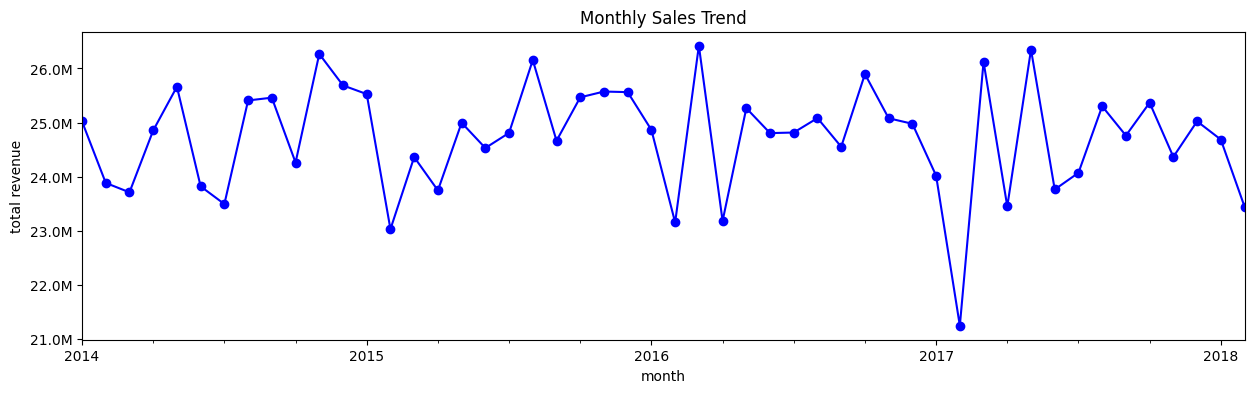

In [43]:
#MONTHLY SALES ANALYSIS OVER TIME
df['order_month'] = df['orderdate'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['line total'].sum()

plt.figure(figsize =(15,4))
monthly_sales.plot(marker ='o', color='blue')

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')


plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Monthly Sales Trend")
plt.xlabel("month")
plt.ylabel("total revenue")
plt.show()

/tmp/ipython-input-2347782057.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data = top10_products, x= 'product name', y= 'line total', palette='tab10')


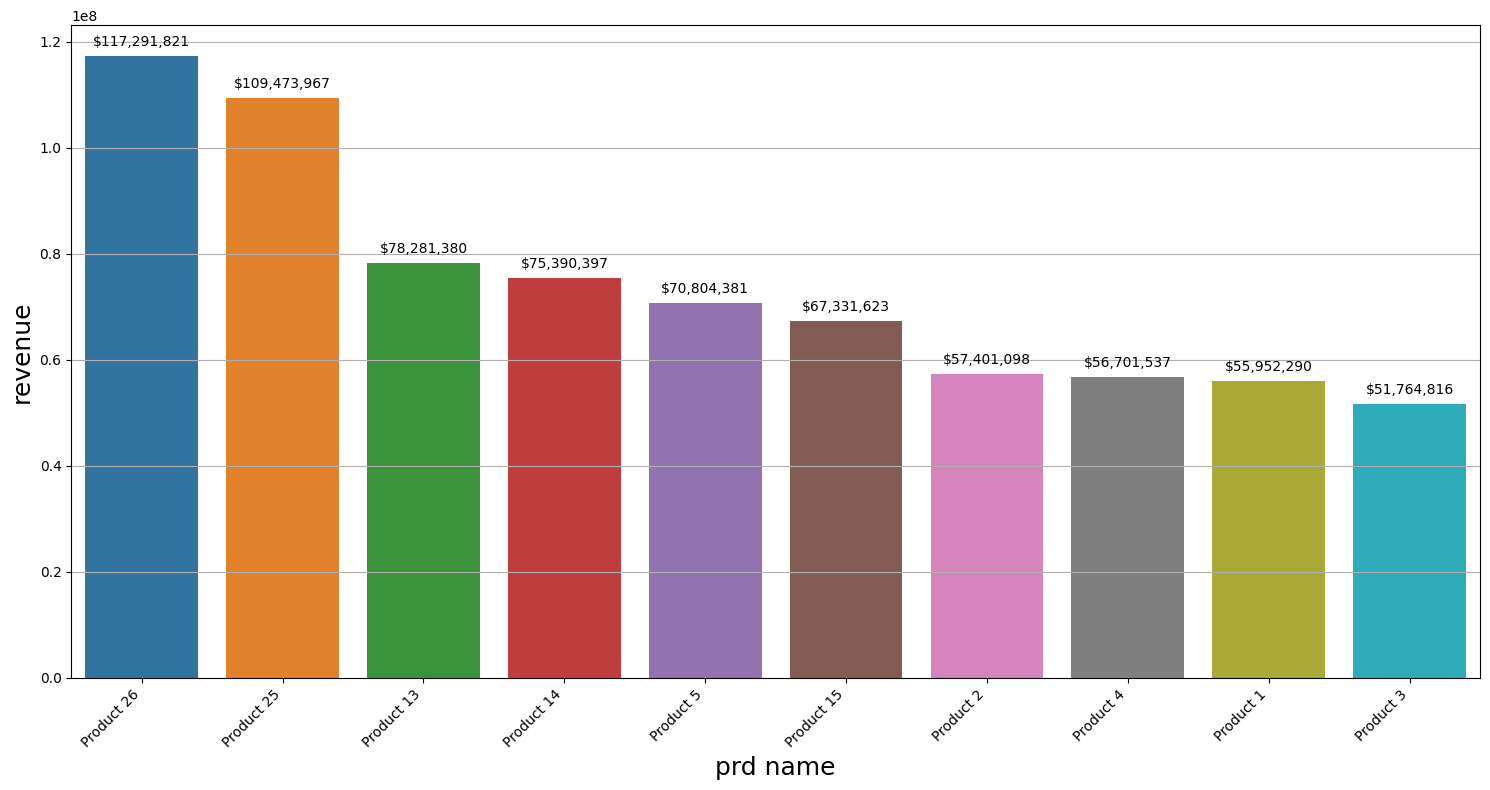

In [44]:
#for top 10 products

prd_revenue = df.groupby('product name')['line total'].sum().reset_index()

top10_products = prd_revenue.sort_values(by='line total', ascending=False).head(10)

plt.figure(figsize=(15,8))
barplot = sns.barplot(data = top10_products, x= 'product name', y= 'line total', palette='tab10')

# add labels on top of the bars
for p in barplot.patches:
  barplot.annotate(f'${p.get_height():,.0f}',
                   (p.get_x() + p.get_width() /2., p.get_height()),
                   ha='center', va='bottom', fontsize=10, color='black',
                   xytext=(0,5) ,textcoords= 'offset points' )



plt.xlabel("prd name", fontsize=18)
plt.ylabel("revenue",fontsize=18)
plt.xticks(rotation =45, ha = 'right')
plt.grid(True, axis= 'y' )
plt.tight_layout()

plt.show()

/tmp/ipython-input-1299510954.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data = top10_products, x= 'product name', y= 'line total', palette='tab10')


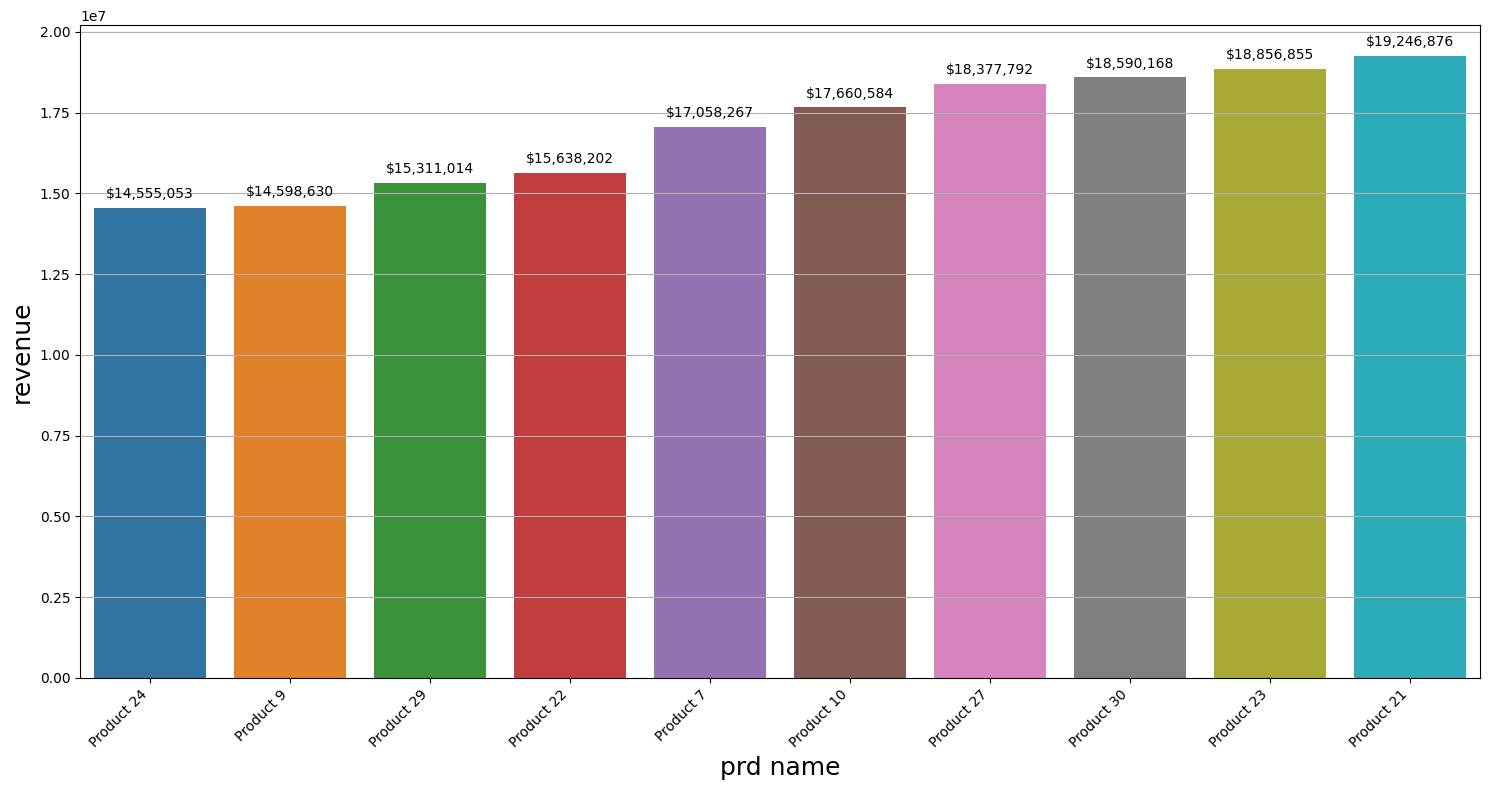

In [45]:
#for bottom 10 products

prd_revenue = df.groupby('product name')['line total'].sum().reset_index()

top10_products = prd_revenue.sort_values(by='line total', ascending=True).head(10)

plt.figure(figsize=(15,8))
barplot = sns.barplot(data = top10_products, x= 'product name', y= 'line total', palette='tab10')

# add labels on top of the bars
for p in barplot.patches:
  barplot.annotate(f'${p.get_height():,.0f}',
                   (p.get_x() + p.get_width() /2., p.get_height()),
                   ha='center', va='bottom', fontsize=10, color='black',
                   xytext=(0,5) ,textcoords= 'offset points' )



plt.xlabel("prd name", fontsize=18)
plt.ylabel("revenue",fontsize=18)
plt.xticks(rotation =45, ha = 'right')
plt.grid(True, axis= 'y' )
plt.tight_layout()

plt.show()

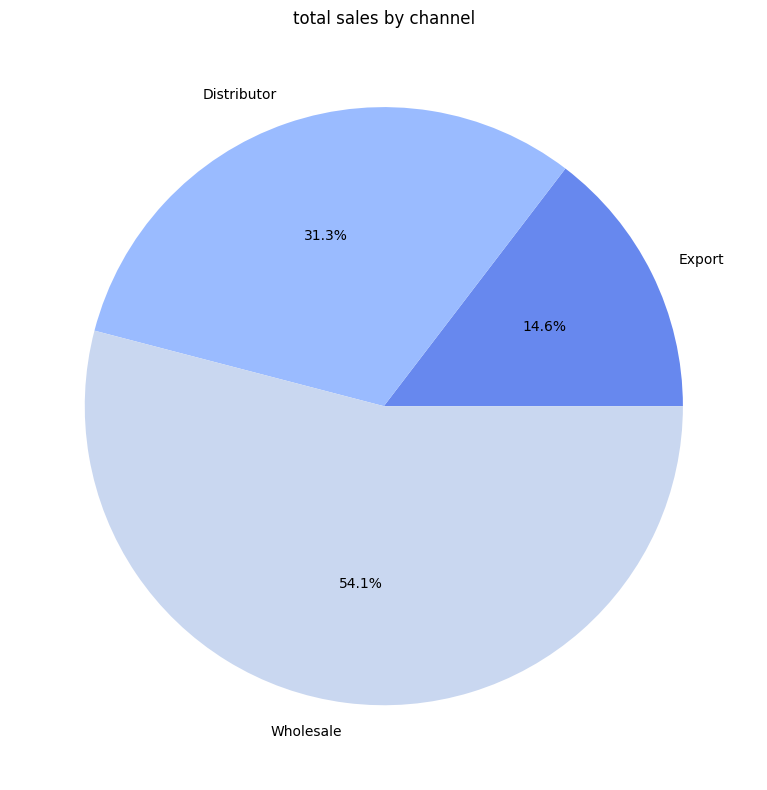

In [46]:
#sales by channel

chan_sales = df.groupby('channel')['line total'].sum().sort_values(ascending = True)

plt.figure(figsize=(8,8))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct = '%1.1f%%',
    colors=sns.color_palette('coolwarm')

)

plt.title('total sales by channel')
plt.tight_layout()

plt.show()

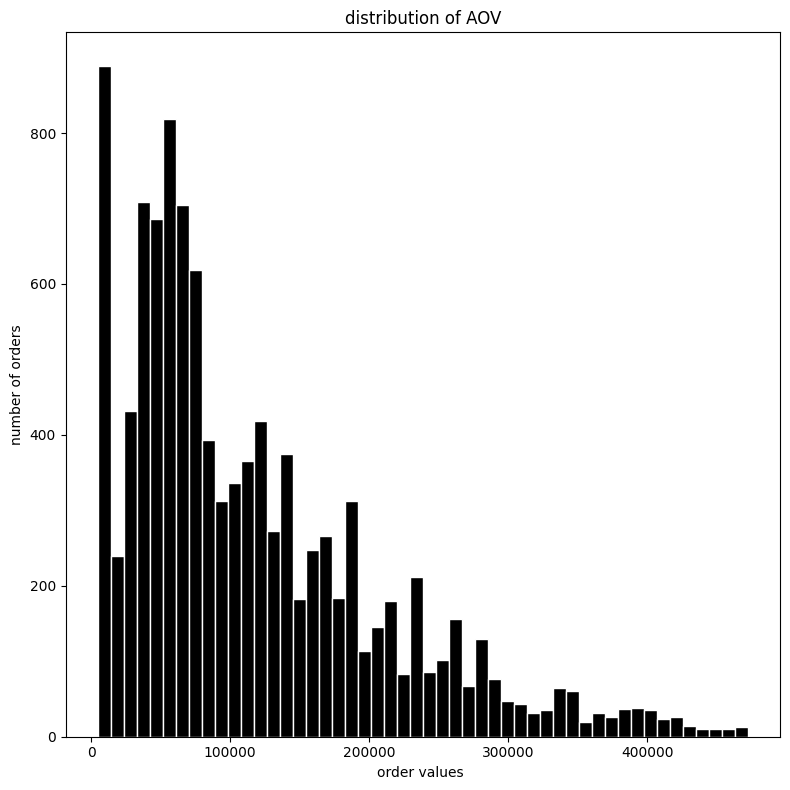

In [47]:
#average oders values(AOV) distribution

aov =  df.groupby('ordernumber')['line total'].sum()

plt.figure(figsize=(8,8))

plt.hist(aov, bins =50 , edgecolor ='white' , color='black')
plt.title('distribution of AOV')
plt.xlabel('order values ')
plt.ylabel('number of orders')

plt.tight_layout()

plt.show()


In [48]:
df.head()

,ordernumber,orderdate,channel,order quantity,unit price,line total,total unit cost,customer names,county,state_code,state,latitude,longitude,region,2017 budgets,product name,total_cost,profit,profit margin pct,order_month
0,SO - 000225,2014-01-01,Wholesale,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,GA,Georgia,32.08354,-81.09983,South,NaN,Product 27,10946.058,4048.542,27.0,2014-01
1,SO - 0003378,2014-01-01,Distributor,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,NaN,Product 20,13969.098,11899.602,46.0,2014-01
2,SO - 0005126,2014-01-01,Wholesale,6,978.2,5869.2,684.740,Amerisourc Corp,Alameda County,CA,California,37.66243,-121.87468,West,NaN,Product 26,4108.440,1760.760,30.0,2014-01
3,SO - 0005614,2014-01-01,Export,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,NaN,Product 7,7201.964,9166.136,56.0,2014-01
4,SO - 0005781,2014-01-01,Wholesale,8,2291.4,18331.2,1260.270,Deseret Group,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,NaN,Product 8,10082.160,8249.040,45.0,2014-01


/tmp/ipython-input-1625371071.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_top_10 , x= 'product name' , y = 'unit price' , palette ='tab10')


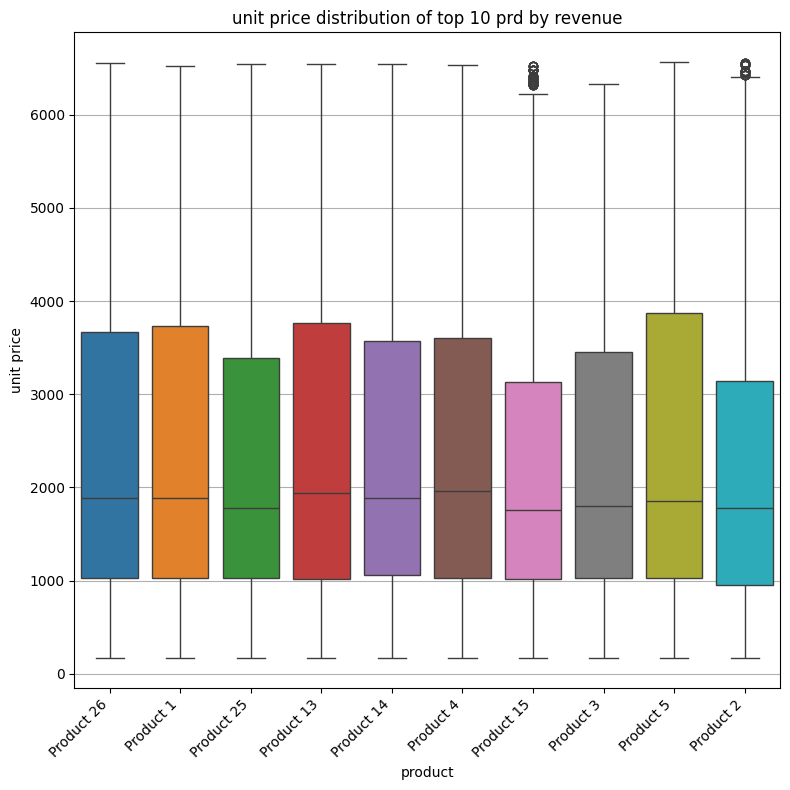

In [49]:
#unit price distribution per product

product_revenue =  df.groupby('product name')['line total'].sum().reset_index()
top_10_products = product_revenue.sort_values(by='line total', ascending=False).head(10)['product name'].tolist()

plt.figure(figsize=(8,8))

df_top_10 = df[df['product name'].isin(top_10_products)]

sns.boxplot(data = df_top_10 , x= 'product name' , y = 'unit price' , palette ='tab10')
plt.title('unit price distribution of top 10 prd by revenue')
plt.xlabel('product')
plt.ylabel('unit price')
plt.xticks(rotation =45, ha = 'right')
plt.grid(True , axis ='y')
plt.tight_layout()

plt.show()

In [50]:
#Top 10 States by Revenue and order count

In [51]:
state_performance = df.groupby('state').agg(
    total_revenue=('line total', 'sum'),
    order_count=('ordernumber', 'count')
).reset_index()

/tmp/ipython-input-2367246868.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=top10_states_revenue, x='state', y='total_revenue', palette='viridis')


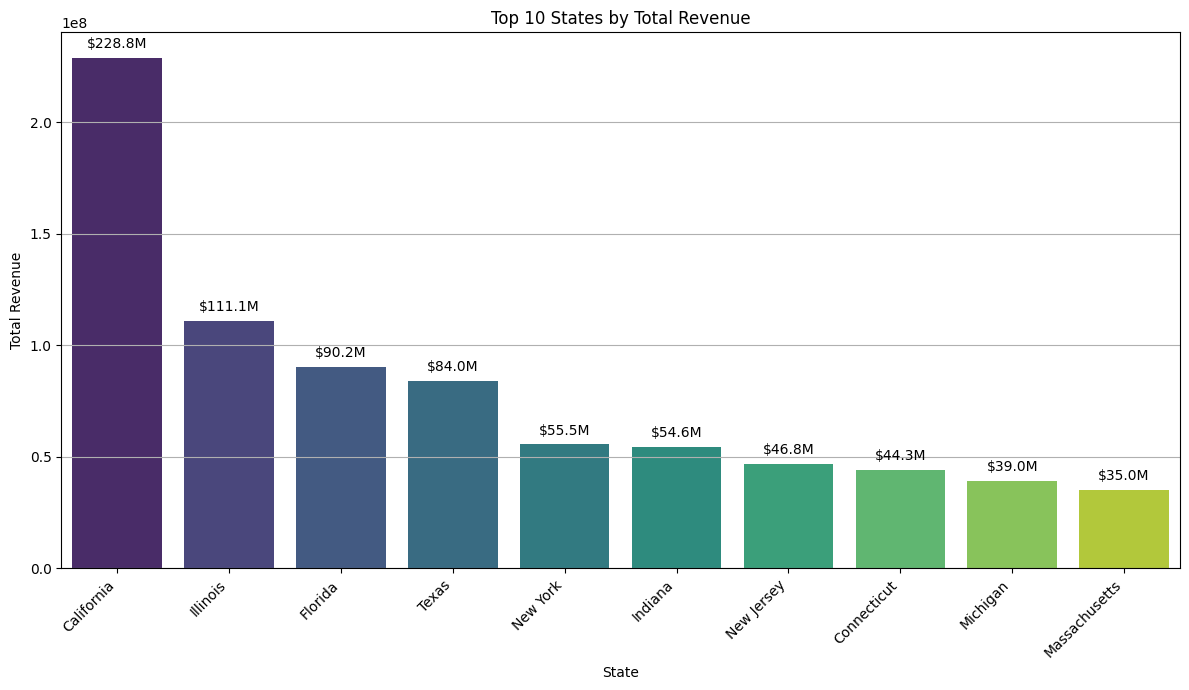

In [52]:
# Top 10 States by Revenue
top10_states_revenue = state_performance.sort_values(by='total_revenue', ascending=False).head(10)

plt.figure(figsize=(12, 7))
barplot = sns.barplot(data=top10_states_revenue, x='state', y='total_revenue', palette='viridis')

for p in barplot.patches:
    barplot.annotate(f'${p.get_height()/1e6:.1f}M',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10, color='black',
                       xytext=(0, 5), textcoords='offset points')

plt.title('Top 10 States by Total Revenue')
plt.xlabel('State')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2829894374.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=top10_states_orders, x='state', y='order_count', palette='magma')


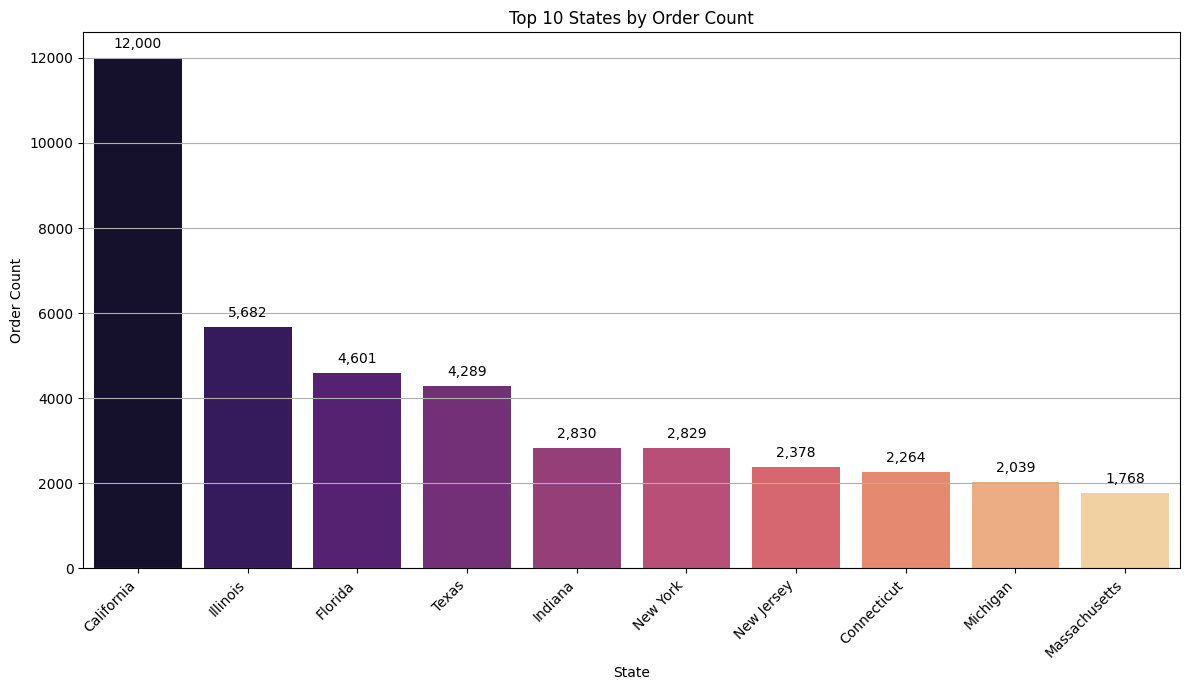

In [53]:
# Top 10 States by Order Count
top10_states_orders = state_performance.sort_values(by='order_count', ascending=False).head(10)

plt.figure(figsize=(12, 7))
barplot = sns.barplot(data=top10_states_orders, x='state', y='order_count', palette='magma')

for p in barplot.patches:
    barplot.annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10, color='black',
                       xytext=(0, 5), textcoords='offset points')

plt.title('Top 10 States by Order Count')
plt.xlabel('State')
plt.ylabel('Order Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3786642006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=avg_profit_margin_by_channel, x='channel', y='profit margin pct', palette='viridis')


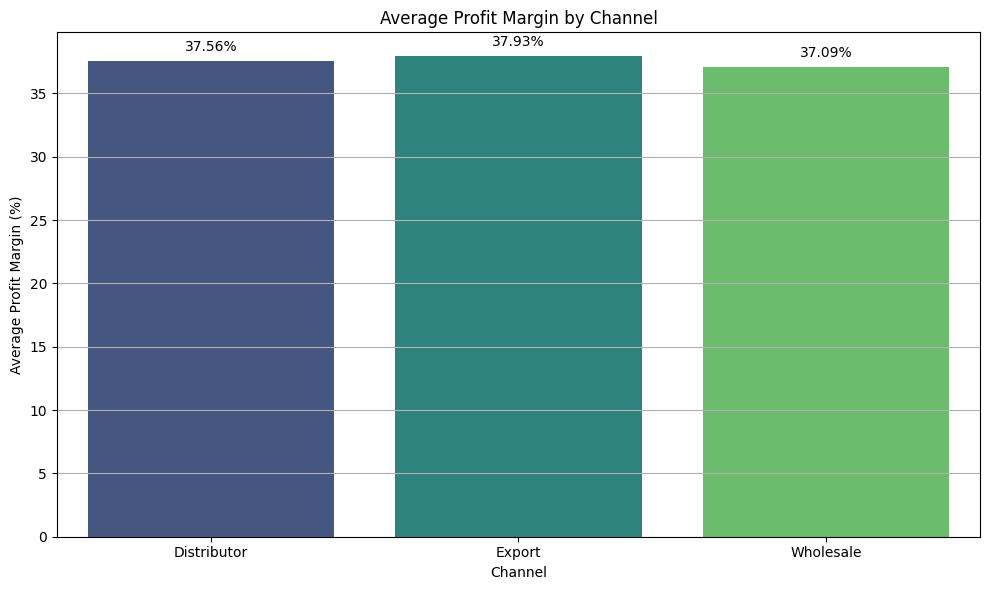

In [54]:
# Top 10 States by Revenue and order count
avg_profit_margin_by_channel = df.groupby('channel')['profit margin pct'].mean().reset_index()

plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=avg_profit_margin_by_channel, x='channel', y='profit margin pct', palette='viridis')

for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}%',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10, color='black',
                       xytext=(0, 5), textcoords='offset points')

plt.title('Average Profit Margin by Channel')
plt.xlabel('Channel')
plt.ylabel('Average Profit Margin (%)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

/tmp/ipython-input-501066069.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_top = sns.barplot(data=top10_customers, x='customer names', y='line total', palette='viridis')


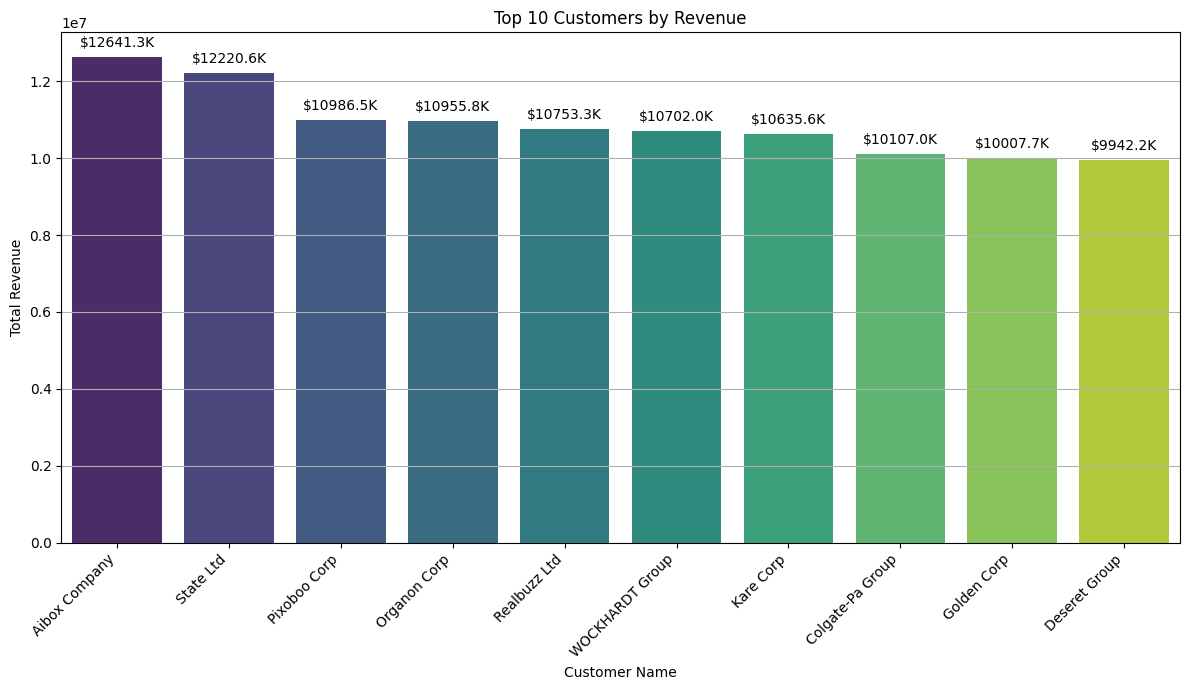

In [55]:
# Top 10 Customers by Revenue
customer_revenue = df.groupby('customer names')['line total'].sum().reset_index()

top10_customers = customer_revenue.sort_values(by='line total', ascending=False).head(10)

plt.figure(figsize=(12, 7))
barplot_top = sns.barplot(data=top10_customers, x='customer names', y='line total', palette='viridis')

for p in barplot_top.patches:
    barplot_top.annotate(f'${p.get_height()/1e3:.1f}K',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10, color='black',
                         xytext=(0, 5), textcoords='offset points')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

/tmp/ipython-input-633047632.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_bottom = sns.barplot(data=bottom10_customers, x='customer names', y='line total', palette='magma')


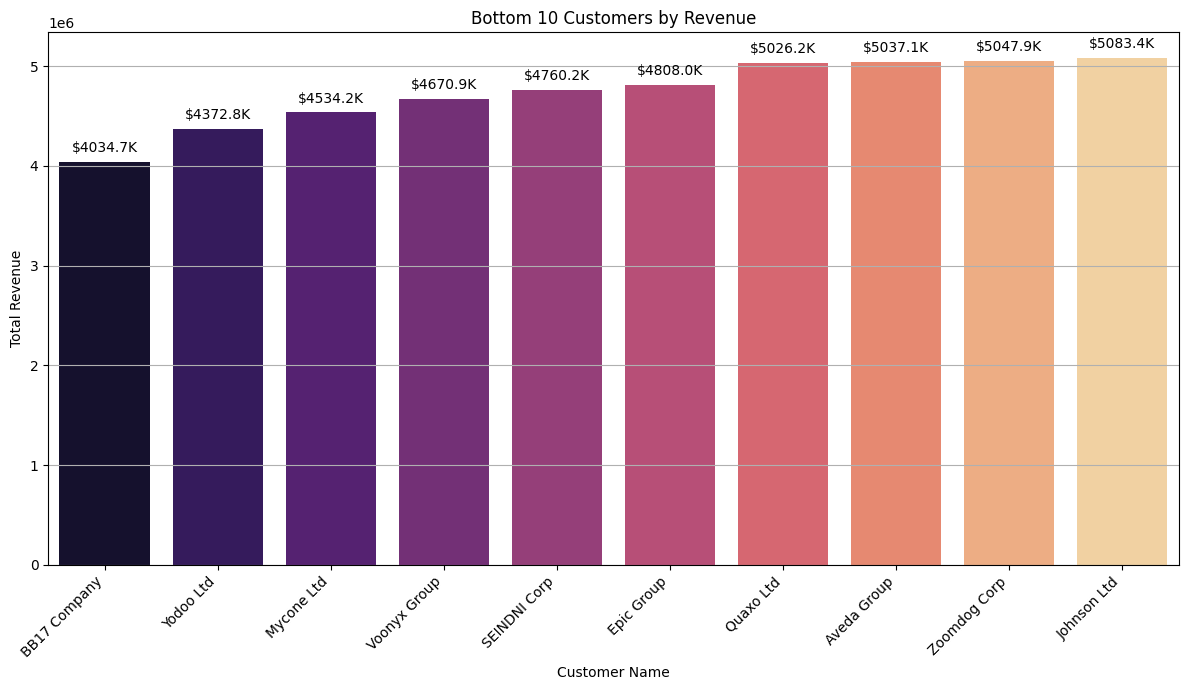

In [56]:
# Bottom 10 Customers by Revenue
bottom10_customers = customer_revenue.sort_values(by='line total', ascending=True).head(10)

plt.figure(figsize=(12, 7))
barplot_bottom = sns.barplot(data=bottom10_customers, x='customer names', y='line total', palette='magma')

for p in barplot_bottom.patches:
    barplot_bottom.annotate(f'${p.get_height()/1e3:.1f}K',
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', fontsize=10, color='black',
                            xytext=(0, 5), textcoords='offset points')

plt.title('Bottom 10 Customers by Revenue')
plt.xlabel('Customer Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

customer seggmentation :revenue vs profit margin


**Reasoning**:
The previous code failed due to incorrect column names. I need to correct the column names for customer names, profit margin, and order number in the `customer_segmentation` calculation and then display the head of the resulting DataFrame.



In [57]:
customer_segmentation = (
    df.groupby("customer names")
      .agg(
          total_revenue=("line total", "sum"),
          total_profit=("profit", "sum"),
          avg_profit_margin=("profit margin pct", "mean"),
          orders = ('ordernumber' ,'nunique')
      )
      .reset_index()
)

customer_segmentation.head()

,customer names,total_revenue,total_profit,avg_profit_margin,orders
0,ALK-Abello Ltd,7662321.0,2956715.226,38.223881,67
1,Accord Group,7116927.6,2828208.288,37.945455,55
2,Accudial Company,5835994.8,2108456.634,36.983607,61
3,Actavis Company,7074074.4,2863854.834,38.761905,63
4,Aibox Company,12641251.8,4946556.936,37.860465,86


**Reasoning**:
The customer segmentation DataFrame has been successfully created and its head displayed. The next step is to prepare the scatter plot for customer segmentation to visualize the relationship between total revenue and average profit margin, as outlined in the main task.



**Reasoning**:
The previous plot produced a UserWarning regarding `plt.tight_layout()` not being able to apply due to overlapping decorations. To address this, I will increase the figure size and use `ax.annotate` with offsets for customer labels, which provides better control over text placement and avoids potential overlap issues with plot boundaries or other elements, allowing `tight_layout` to function more effectively.



# Task
Visualize customer segmentation by creating a scatter plot of 'total_revenue' (log scale) against 'avg_profit_margin' using the `customer_segmentation` DataFrame. Color the points by `avg_profit_margin` and size them by `total_revenue`. Annotate the top 5 customers by revenue, add appropriate titles and labels, and move the legend outside the plot.

## Visualize Customer Segmentation

### Subtask:
Create a scatter plot of 'total_revenue' (log scale) against 'avg_profit_margin' using the `customer_segmentation` DataFrame. Color the points by `avg_profit_margin` and size them by `total_revenue`. Annotate the top 5 customers by revenue, add appropriate titles and labels, and move the legend outside the plot.


**Reasoning**:
I need to create a scatter plot for customer segmentation as per the instructions. This involves preparing the plot with specific axes, colors, sizes, and annotations for the top 5 customers, and moving the legend outside the plot area.



**Reasoning**:
The previous code failed because `plt` was not defined. I need to import `matplotlib.pyplot` to use `plt` functions for plotting.



/tmp/ipython-input-3294321702.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


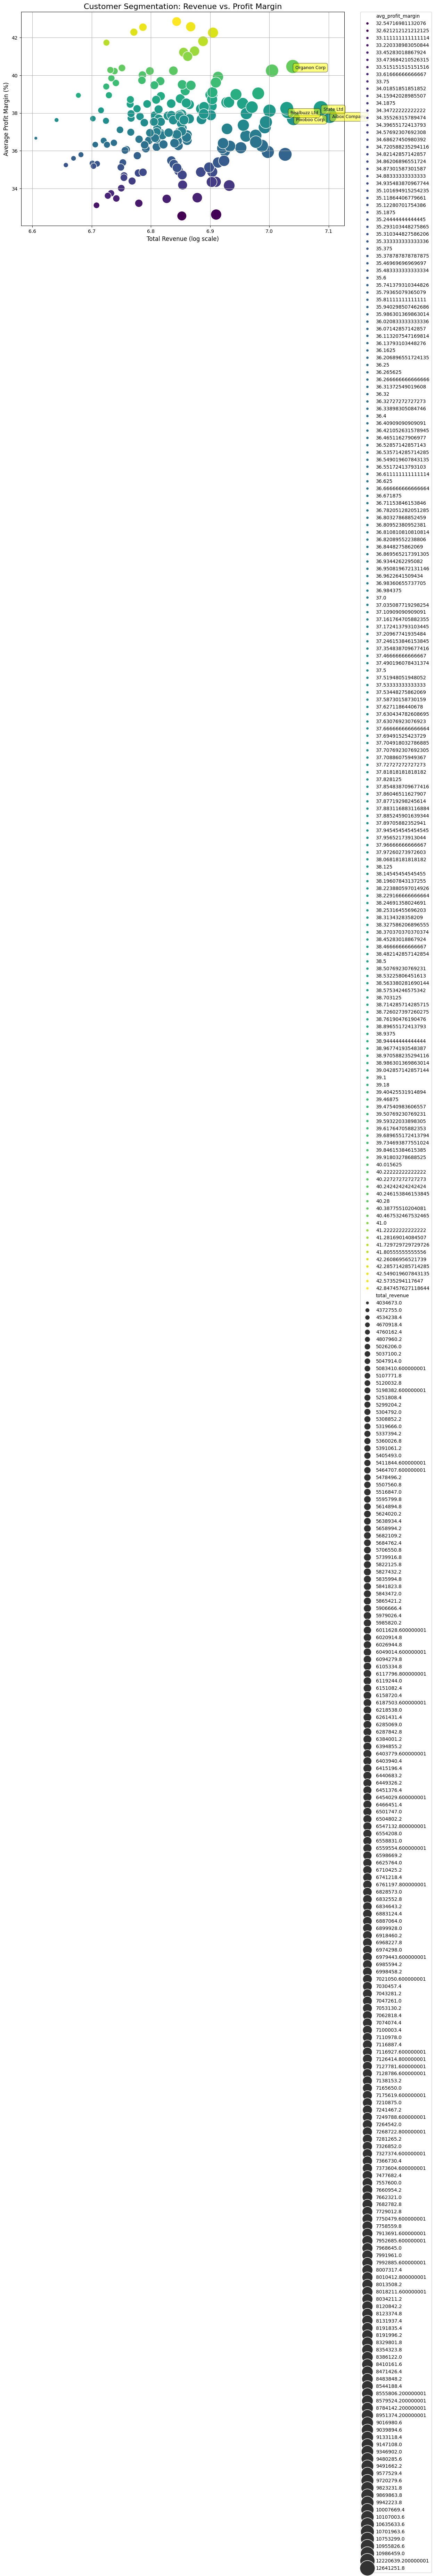

In [60]:


plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    data=customer_segmentation,
    x=np.log10(customer_segmentation['total_revenue']),
    y='avg_profit_margin',
    hue='avg_profit_margin',
    size='total_revenue',
    sizes=(50, 1000),
    palette='viridis',
    legend='full'
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin', fontsize=16)
plt.xlabel('Total Revenue (log scale)', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)

# Identify top 5 customers by total_revenue
top5_customers = customer_segmentation.sort_values(by='total_revenue', ascending=False).head(5)

# Annotate the top 5 customers
for i, row in top5_customers.iterrows():
    ax.annotate(row['customer names'],
                xy=(np.log10(row['total_revenue']), row['avg_profit_margin']),
                xytext=(5, -5), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=0.2', color='gray'),
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                fontsize=9)

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code failed because `sns` (seaborn) and `np` (numpy) were not defined. I need to import both `seaborn` and `numpy` in addition to `matplotlib.pyplot` to use their functions for plotting and numerical operations.



**Reasoning**:
The previous errors indicated that `plt`, `sns`, and `np` were not defined. The provided code block now correctly imports `matplotlib.pyplot`, `seaborn`, and `numpy` which will resolve these `NameError` issues.



# Task
Adjust the scatter plot to display customer segmentation by removing the detailed legend for `avg_profit_margin` and instead use a color bar to represent the continuous profit margin range. Ensure the plot retains its clear titles, labels, and annotations for the top 5 customers. After refining the plot, provide a concise summary of the customer segmentation insights derived from it, highlighting key customer behaviors or segments.

## Refine Customer Segmentation Plot

### Subtask:
Adjust the scatter plot by removing the detailed legend for 'avg_profit_margin' and utilizing the color bar to represent the continuous profit margin range. Ensure that the plot remains clear, with appropriate titles, labels, and annotations for the top 5 customers.


**Reasoning**:
The previous code produced a UserWarning regarding `tight_layout` due to overlapping elements and included a redundant legend. To address these issues and refine the customer segmentation plot as instructed, I will remove the detailed legend by setting `legend=False` in `sns.scatterplot`, add a color bar to represent the `avg_profit_margin`, and remove the unnecessary `plt.legend()` call. I will also increase the figure size for better annotation display.



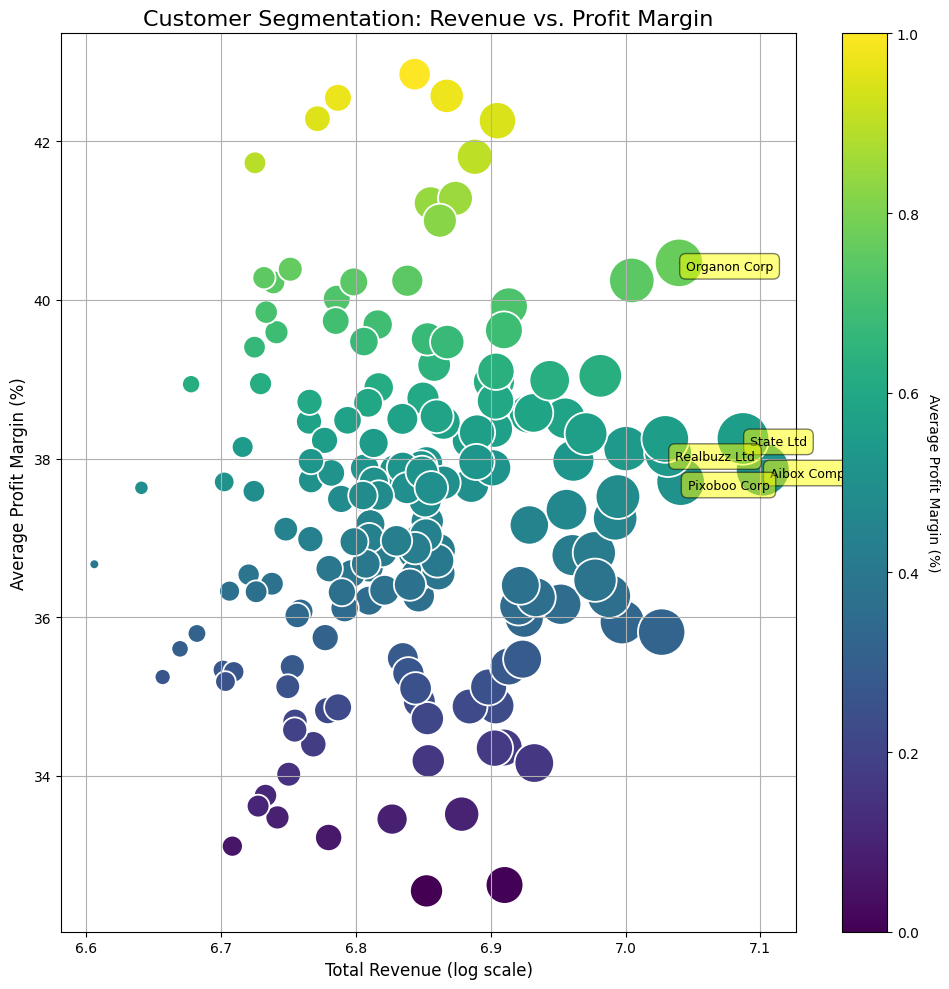

In [62]:
plt.figure(figsize=(10, 10)) # Increased figure size
ax = sns.scatterplot(
    data=customer_segmentation,
    x=np.log10(customer_segmentation['total_revenue']),
    y='avg_profit_margin',
    hue='avg_profit_margin',
    size='total_revenue',
    sizes=(50, 1500), # Adjusted size range for better visibility
    palette='viridis',
    legend=False # Removed the detailed legend
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin', fontsize=16)
plt.xlabel('Total Revenue (log scale)', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)

# Add a color bar to represent avg_profit_margin
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Average Profit Margin (%)', rotation=270, labelpad=15)

# Identify top 5 customers by total_revenue
top5_customers = customer_segmentation.sort_values(by='total_revenue', ascending=False).head(5)

# Annotate the top 5 customers with better placement
for i, row in top5_customers.iterrows():
    ax.annotate(row['customer names'],
                xy=(np.log10(row['total_revenue']), row['avg_profit_margin']),
                xytext=(5, -5), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=0.2', color='gray'),
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                fontsize=9)

plt.grid(True)
plt.tight_layout() # This should now work better with increased figure size and no legend overlap
plt.show()

### Customer Segmentation Insights

The refined scatter plot provides valuable insights into customer segmentation based on revenue and profit margin:

*   **High-Value Customers:** The top 5 annotated customers clearly stand out with significantly higher total revenues. These customers also generally exhibit healthy average profit margins, indicating they are crucial for both revenue generation and profitability. This segment warrants special attention for retention and upselling strategies.

*   **Consistent Profitability:** A large cluster of customers shows similar average profit margins, ranging approximately between 35% and 40%. This suggests that for a majority of customers, the company maintains a stable profit margin, regardless of their total revenue contribution.

*   **Revenue Disparity:** There is a wide distribution of total revenue among customers, ranging from very high (right side of the log-scaled x-axis) to relatively low (left side). This highlights the need for differentiated strategies, possibly focusing on nurturing lower-revenue customers to increase their spending or identifying characteristics of high-revenue customers to replicate success.

*   **Potential Opportunities:** While most customers maintain a consistent profit margin, a few outliers might exist with unusually high or low margins for their revenue level. Investigating these could reveal opportunities for process optimization (for low-margin customers) or best practices (for high-margin customers).

## Final Task

### Subtask:
Provide a concise summary of the customer segmentation insights derived from the refined scatter plot, emphasizing key customer behaviors or segments.


## Summary:

### Q&A
The customer segmentation insights derived from the refined scatter plot, emphasizing key customer behaviors or segments, are:
*   **High-Value Customers:** The top 5 customers are crucial for both revenue generation and profitability, exhibiting significantly higher total revenues and healthy average profit margins.
*   **Consistent Profitability:** A large segment of customers maintains consistent average profit margins, typically between 35% and 40%, irrespective of their total revenue.
*   **Revenue Disparity:** There's a broad range of total revenue contributions among customers, highlighting varying customer engagement levels.
*   **Potential Opportunities:** Outliers with unusually high or low profit margins for their revenue level suggest areas for optimization or identifying best practices.

### Data Analysis Key Findings
*   The top 5 customers, identified by their total revenue, are significant contributors and generally display healthy average profit margins.
*   A substantial portion of customers shows consistent average profit margins, clustering between approximately 35% and 40%.
*   Customer total revenue spans a wide range, from very high to relatively low, indicating a diverse customer base.
*   The refined plot successfully replaced the detailed legend for `avg_profit_margin` with a color bar, enhancing clarity while retaining annotations for the top 5 customers.

### Insights or Next Steps
*   Develop targeted retention and upselling strategies for the identified high-value customers to maximize their lifetime value.
*   Investigate the characteristics of high-revenue customers to understand their success factors, and explore differentiated strategies to nurture lower-revenue customers, potentially increasing their spending.


In [ ]:
# correlation Heaptmap of numeric

### Correlation Heatmap of Numeric Features

This heatmap visualizes the Pearson correlation coefficients between all numeric columns in the dataset. The color intensity and scale indicate the strength and direction of the correlation:

*   **Positive Correlation (Warmer colors):** Indicates that as one variable increases, the other tends to increase as well.
*   **Negative Correlation (Cooler colors):** Indicates that as one variable increases, the other tends to decrease.
*   **Values close to 1 or -1:** Represent very strong positive or negative correlations, respectively.
*   **Values close to 0:** Indicate a weak or no linear correlation.

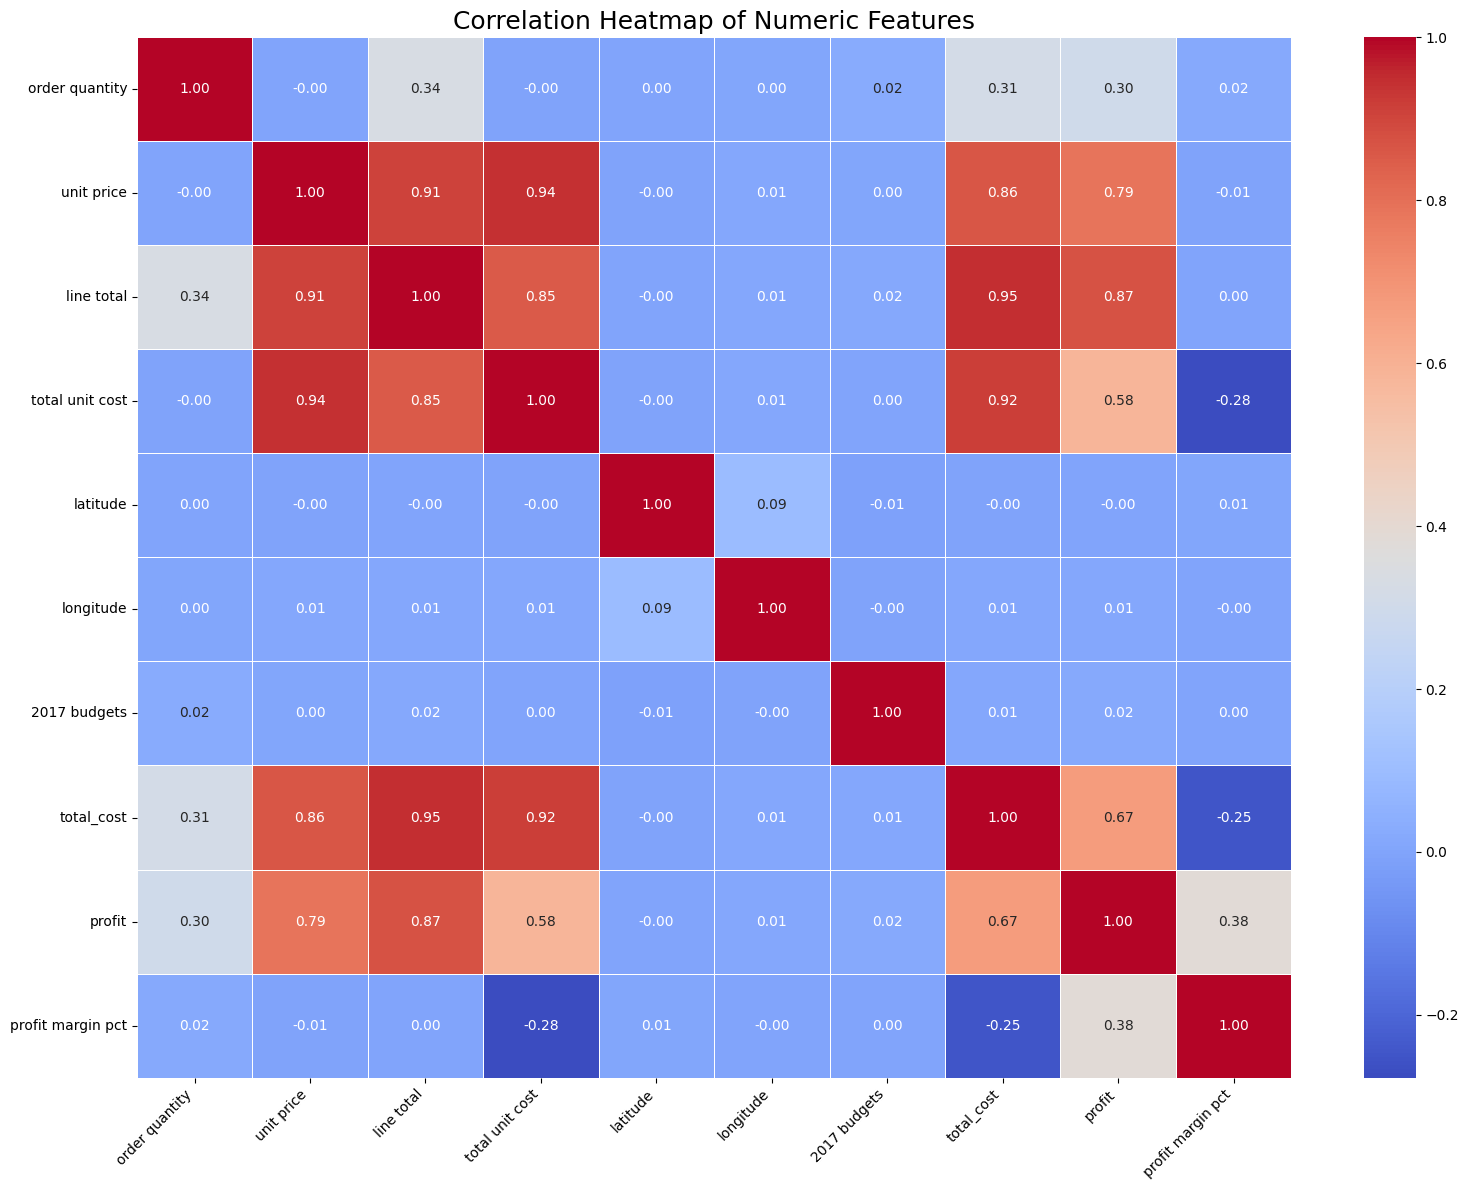

In [63]:
# Select only numeric columns for correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

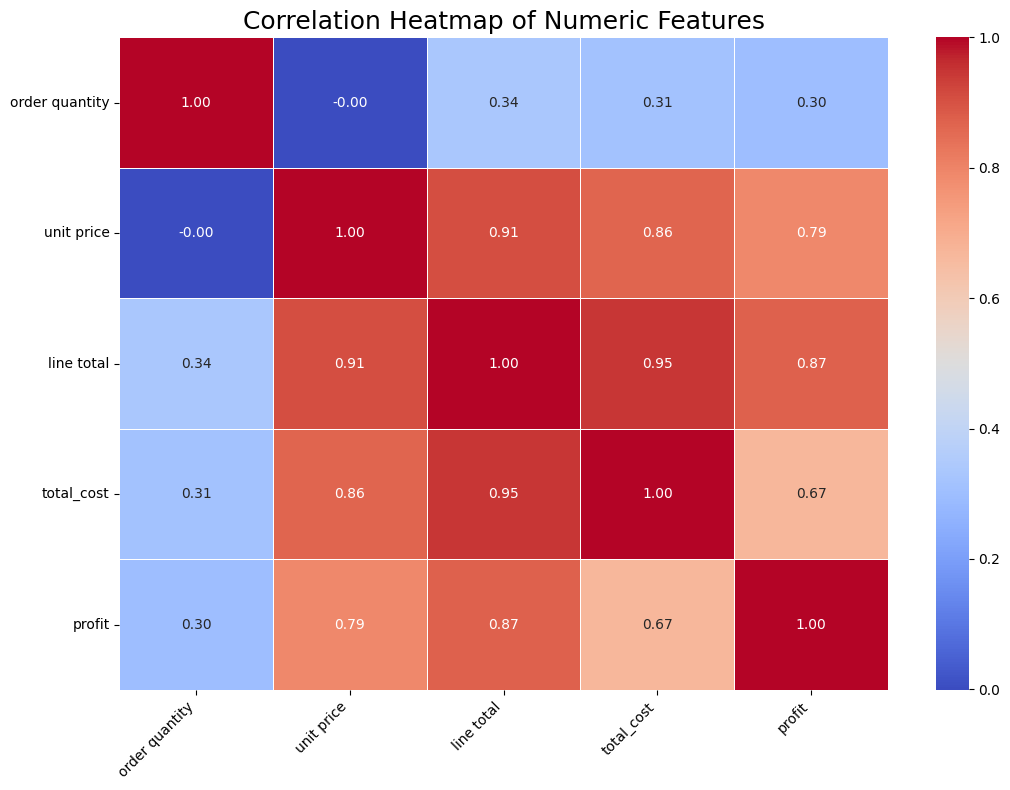

In [70]:
# Select only numeric columns for correlation heatmap
numeric_df = ['order quantity', 'unit price' ,'line total', 'total_cost','profit']

# Calculate the correlation matrix
correlation_matrix = df[numeric_df].corr()

# Plot the heatmap
plt.figure(figsize=(11, 8)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()